## Get some images

Get some example images to practice with. You will need multiple images to be able to visualize your dataset once you extract features.

Remember this function from week 2? It returns the loaded img and its mask given an `img_id`. It's always nice to make some code reusable :)

In [3]:
import matplotlib.pyplot as plt
data_path = '../data/'

def load_image_and_mask(image_id, data_path=data_path):
    '''
    Docstring for load_image
    
    :param image_id: "img_id" from metadata.csv
    :param data_path: Relative path of the data folder

    This functions takes as input an image ID, 
    and returns the corresponding image and mask 
    (found in "/data/imgs/" and "/data/masks/" respectively)
    as an array
    '''
    
    img_path = data_path + "imgs/"
    mask_path = data_path + "masks/"

    # Load the image/mask
    file_im = img_path + image_id
    file_mask = (mask_path + image_id).replace(".png", "_mask.png")
    im = plt.imread(file_im)
    mask = plt.imread(file_mask)
    
    return im, mask

## Try out some ABC feature extraction

The cell below contains implementations made by previous years's groups. Feel free to move the content of the cell to a separate python script. Some features are implemented multiple times. Not all implementations are good, useful, or commented. Not all imports are needed. For your project you will need to investigate which you want to use or not, and motivate your choices. You can also modify the implementations.

In [4]:
import cv2
import numpy as np
from math import sqrt, floor, ceil, nan, pi
from skimage import color, exposure
from skimage.color import rgb2gray
from skimage.feature import blob_log
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage.transform import rotate
from skimage import morphology
from sklearn.cluster import KMeans
from skimage.segmentation import slic
from skimage.color import rgb2hsv
from scipy.stats import circmean, circvar, circstd
from statistics import variance, stdev
from scipy.spatial import ConvexHull


def get_compactness(mask):
    # mask = color.rgb2gray(mask)
    area = np.sum(mask)

    struct_el = morphology.disk(3)
    mask_eroded = morphology.binary_erosion(mask, struct_el)
    perimeter = np.sum(mask - mask_eroded)

    return perimeter**2 / (4 * np.pi * area)

def get_asymmetry(mask):
    # mask = color.rgb2gray(mask)
    scores = []
    for _ in range(6):
        segment = crop(mask)
        (np.sum(segment))
        scores.append(np.sum(np.logical_xor(segment, np.flip(segment))) / (np.sum(segment)))
        mask = rotate(mask, 30)
    return sum(scores) / len(scores)

def get_multicolor_rate(im, mask, n):
    # mask = color.rgb2gray(mask)
    im = resize(im, (im.shape[0] // 4, im.shape[1] // 4), anti_aliasing=True)
    mask = resize(
        mask, (mask.shape[0] // 4, mask.shape[1] // 4), anti_aliasing=True
    )
    im2 = im.copy()
    im2[mask == 0] = 0

    columns = im.shape[0]
    rows = im.shape[1]
    col_list = []
    for i in range(columns):
        for j in range(rows):
            if mask[i][j] != 0:
                col_list.append(im2[i][j] * 256)

    if len(col_list) == 0:
        return ""

    cluster = KMeans(n_clusters=n, n_init=10).fit(col_list)
    com_col_list = get_com_col(cluster, cluster.cluster_centers_)

    dist_list = []
    m = len(com_col_list)

    if m <= 1:
        return ""

    for i in range(0, m - 1):
        j = i + 1
        col_1 = com_col_list[i]
        col_2 = com_col_list[j]
        dist_list.append(
            np.sqrt(
                (col_1[0] - col_2[0]) ** 2
                + (col_1[1] - col_2[1]) ** 2
                + (col_1[2] - col_2[2]) ** 2
            )
        )
    return np.max(dist_list)

def get_com_col(cluster, centroids):
    com_col_list = []
    labels = np.arange(0, len(np.unique(cluster.labels_)) + 1)
    (hist, _) = np.histogram(cluster.labels_, bins=labels)
    hist = hist.astype("float")
    hist /= hist.sum()

    rect = np.zeros((50, 300, 3), dtype=np.uint8)
    colors = sorted([(percent, color) for (percent, color) in zip(hist, centroids)], key= lambda x:x[0])
    start = 0
    for percent, color in colors:
        if percent > 0.08:
            com_col_list.append(color)
        end = start + (percent * 300)
        cv2.rectangle(
            rect,
            (int(start), 0),
            (int(end), 50),
            color.astype("uint8").tolist(),
            -1,
        )
        start = end
    return com_col_list

def crop(mask):
        mid = midpointGroup4(mask)
        y_nonzero, x_nonzero = np.nonzero(mask)
        y_lims = [np.min(y_nonzero), np.max(y_nonzero)]
        x_lims = np.array([np.min(x_nonzero), np.max(x_nonzero)])
        x_dist = max(np.abs(x_lims - mid))
        x_lims = [mid - x_dist, mid+x_dist]
        return mask[y_lims[0]:y_lims[1], x_lims[0]:x_lims[1]]

def midpointGroup4(mask):
        summed = np.sum(mask, axis=0)
        half_sum = np.sum(summed) / 2
        for i, n in enumerate(np.add.accumulate(summed)):
            if n > half_sum:
                return i

###################################### Group 9 ####################################################################

def cut_mask(mask):
    '''Cut empty space from mask array such that it has smallest possible dimensions.

    Args:
        mask (numpy.ndarray): mask to cut

    Returns:
        cut_mask_ (numpy.ndarray): cut mask
    '''
    col_sums = np.sum(mask, axis=0)
    row_sums = np.sum(mask, axis=1)

    active_cols = []
    for index, col_sum in enumerate(col_sums):
        if col_sum != 0:
            active_cols.append(index)

    active_rows = []
    for index, row_sum in enumerate(row_sums):
        if row_sum != 0:
            active_rows.append(index)

    col_min = active_cols[0]
    col_max = active_cols[-1]
    row_min = active_rows[0]
    row_max = active_rows[-1]

    cut_mask_ = mask[row_min:row_max+1, col_min:col_max+1]

    return cut_mask_

def cut_im_by_mask(image, mask):
    '''Cut image array such that it has smallest possible dimensions in accordance with its mask.

    Args:
        image (numpy.ndarray): image to cut
        mask (numpy.ndarray): mask of image to use for cutting

    Returns:
        cut_image (numpy.ndarray): cut image
    '''

    col_sums = np.sum(mask, axis=0)
    row_sums = np.sum(mask, axis=1)

    active_cols = []
    for index, col_sum in enumerate(col_sums):
        if col_sum != 0:
            active_cols.append(index)

    active_rows = []
    for index, row_sum in enumerate(row_sums):
        if row_sum != 0:
            active_rows.append(index)

    col_min = active_cols[0]
    col_max = active_cols[-1]
    row_min = active_rows[0]
    row_max = active_rows[-1]

    cut_image = image[row_min:row_max+1, col_min:col_max+1]

    return cut_image

def midpointGroup9(image):
    '''Find midpoint of image array.'''
    row_mid = image.shape[0] / 2
    col_mid = image.shape[1] / 2
    return row_mid, col_mid

def asymmetry(mask):
    '''Calculate asymmetry score between 0 and 1 from vertical and horizontal axis
    on a binary mask, 0 being complete symmetry, 1 being complete asymmetry,
    i.e. no pixels overlapping when folding mask on x- and y-axis

    Args:
        mask (numpy.ndarray): input mask

    Returns:
        asymmetry_score (float): Float between 0 and 1 indicating level of asymmetry.
    '''

    row_mid, col_mid = midpointGroup9(mask)

    # Split mask into halves hortizontally and vertically
    upper_half = mask[:ceil(row_mid), :]
    lower_half = mask[floor(row_mid):, :]
    left_half = mask[:, :ceil(col_mid)]
    right_half = mask[:, floor(col_mid):]

    # Flip one half for each axis
    flipped_lower = np.flip(lower_half, axis=0)
    flipped_right = np.flip(right_half, axis=1)

    # Use logical xor to find pixels where only one half is present
    hori_xor_area = np.logical_xor(upper_half, flipped_lower)
    vert_xor_area = np.logical_xor(left_half, flipped_right)

    # Compute sums of total pixels and pixels in asymmetry areas
    total_pxls = np.sum(mask)
    hori_asymmetry_pxls = np.sum(hori_xor_area)
    vert_asymmetry_pxls = np.sum(vert_xor_area)

    # Calculate asymmetry score
    asymmetry_score = (hori_asymmetry_pxls + vert_asymmetry_pxls) / (total_pxls * 2)

    return round(asymmetry_score, 4)

def rotation_asymmetry(mask, n: int):
    '''Rotate mask n times and calculate asymmetry score for each iteration.
    Rotates n times between 0 and 90 degrees, as 90 degree rotations do not change the
    asymmetry score, i.e., a 30 degree rotation is the same as a 120 degree rotation.

    Args:
        mask (numpy.ndarray): input mask
        n (int): amount of rotations

    Returns:
        asymmetry_scores (dict): dict of asymmetry scores calculated from each rotation.
    '''
    asymmetry_scores = {}

    for i in range(n):

        degrees = 90 * i / n

        rotated_mask = rotate(mask, degrees)
        cutted_mask = cut_mask(rotated_mask)

        asymmetry_scores[degrees] = asymmetry(cutted_mask)

    return asymmetry_scores

def mean_asymmetry(mask, rotations = 30):
    '''Return mean asymmetry score from mask.
    Optional argument (defualt 30) rotations decides amount of rotations in asymmetry calculation

    Args:
        mask (numpy.ndarray): mask to compute asymmetry score for
        rotations (int, optional): amount of rotations (default 30)

    Returns:
        mean_score (float): mean asymmetry score.
    '''
    asymmetry_scores = rotation_asymmetry(mask, rotations)
    mean_score = sum(asymmetry_scores.values()) / len(asymmetry_scores)

    return mean_score

def best_asymmetry(mask, rotations = 30):
    '''Return best (lowest) asymmetry score from mask.
    Optional argument (defualt 30) rotations decides amount of rotations in asymmetry calculation

    Args:
        mask (numpy.ndarray): mask to compute asymmetry score for
        rotations (int, optional): amount of rotations (defualt 30)

    Returns:
        best_score (float): best asymmetry score.
    '''
    asymmetry_scores = rotation_asymmetry(mask, rotations)
    best_score = min(asymmetry_scores.values())

    return best_score

def worst_asymmetry(mask, rotations = 30):
    '''Return worst (highest) asymmetry score from mask.
    Optional argument (defualt 30) rotations decides amount of rotations in asymmetry calculation

    Args:
        mask (numpy.ndarray): mask to compute asymmetry score for
        rotations (int, optional): amount of rotations (defualt 30)

    Returns:
        worst_score (float): worst asymmetry score.
    '''
    asymmetry_scores = rotation_asymmetry(mask, rotations)
    worst_score = max(asymmetry_scores.values())

    return worst_score

def slic_segmentation(image, mask, n_segments = 50, compactness = 0.1):
    '''Get color segments of lesion from SLIC algorithm.
    Optional argument n_segments (defualt 50) defines desired amount of segments.
    Optional argument compactness (defualt 0.1) defines balance between color
    and position.

    Args:
        image (numpy.ndarray): image to segment
        mask (numpy.ndarray):  image mask
        n_segments (int, optional): desired amount of segments
        compactness (float, optional): compactness score, decides balance between
            color and and position

    Returns:
        slic_segments (numpy.ndarray): SLIC color segments.
    '''
    slic_segments = slic(image,
                    n_segments = n_segments,
                    compactness = compactness,
                    sigma = 1,
                    mask = mask,
                    start_label = 1,
                    channel_axis = 2)

    return slic_segments

def get_rgb_means(image, slic_segments):
    '''Get mean RGB values for each segment in a SLIC segmented image.

    Args:
        image (numpy.ndarray): original image
        slic_segments (numpy.ndarray): SLIC segmentation

    Returns:
        rgb_means (list): RGB mean values for each segment.
    '''

    max_segment_id = np.unique(slic_segments)[-1]

    rgb_means = []
    for i in range(1, max_segment_id + 1):

        #Create masked image where only specific segment is active
        segment = image.copy()
        segment[slic_segments != i] = -1

        #Get average RGB values from segment
        rgb_mean = np.mean(segment, axis = (0, 1), where = (segment != -1))

        rgb_means.append(rgb_mean)

    return rgb_means

def get_hsv_means(image, slic_segments):
    '''Get mean HSV values for each segment in a SLIC segmented image.

    Args:
        image (numpy.ndarray): original image
        slic_segments (numpy.ndarray): SLIC segmentation

    Returns:
        hsv_means (list): HSV mean values for each segment.
    '''

    hsv_image = rgb2hsv(image)

    max_segment_id = np.unique(slic_segments)[-1]

    hsv_means = []
    for i in range(1, max_segment_id + 1):

        # Create masked image where only specific segment is active
        segment = hsv_image.copy()
        segment[slic_segments != i] = nan

        #Get average HSV values from segment
        hue_mean = circmean(segment[:, :, 0], high=1, low=0, nan_policy='omit') # Compute circular hue mean
        sat_mean = np.mean(segment[:, :, 1], where = (slic_segments == i)) # Compute saturation mean
        val_mean = np.mean(segment[:, :, 2], where = (slic_segments == i)) # Compute value mean

        hsv_mean = np.asarray([hue_mean, sat_mean, val_mean])

        hsv_means.append(hsv_mean)

    return hsv_means

def rgb_var(image, slic_segments):
    '''Get variance of RGB means for each segment in
    SLIC segmentation in red, green and blue channels

    Args:
        image (numpy.ndarray): image to compute color variance for
        slic_segments (numpy.ndarray): array containing SLIC segmentation

    Returns:
        red_var (float): variance in red channel segment means
        green_var (float): variance in green channel segment means
        blue_var (float): variance in green channel segment means.
    '''

    # If there is only 1 slic segment, return (0, 0, 0)
    if len(np.unique(slic_segments)) == 2: # Use 2 since slic_segments also has 0 for area outside mask
        return 0, 0, 0

    rgb_means = get_rgb_means(image, slic_segments)
    n = len(rgb_means) # Amount of segments, used later to compute variance

    # Seperate and collect channel means together in lists
    red = []
    green = []
    blue = []
    for rgb_mean in rgb_means:
        red.append(rgb_mean[0])
        green.append(rgb_mean[1])
        blue.append(rgb_mean[2])

    # Compute variance for each channel seperately
    red_var = variance(red, sum(red)/n)
    green_var = variance(green, sum(green)/n)
    blue_var = variance(blue, sum(blue)/n)

    return red_var, green_var, blue_var

def hsv_var(image, slic_segments):
    '''Get variance of HSV means for each segment in
    SLIC segmentation in hue, saturation and value channels

    Args:
        image (numpy.ndarray): image to compute color variance for
        slic_segments (numpy.ndarray): array containing SLIC segmentation

    Returns:
        hue_var (float): variance in hue channel segment means
        sat_var (float): variance in saturation channel segment means
        val_var (float): variance in value channel segment means.
    '''

    # If there is only 1 slic segment, return (0, 0, 0)
    if len(np.unique(slic_segments)) == 2: # Use 2 since slic_segments also has 0 marking for area outside mask
        return 0, 0, 0

    hsv_means = get_hsv_means(image, slic_segments)
    n = len(hsv_means) # Amount of segments, used later to compute variance

    # Seperate and collect channel means together in lists
    hue = []
    sat = []
    val = []
    for hsv_mean in hsv_means:
        hue.append(hsv_mean[0])
        sat.append(hsv_mean[1])
        val.append(hsv_mean[2])

    # Compute variance for each channel seperately
    hue_var = circvar(hue, high=1, low=0)
    sat_var = variance(sat, sum(sat)/n)
    val_var = variance(val, sum(val)/n)

    return hue_var, sat_var, val_var


def color_dominance(image, mask, clusters = 5, include_ratios = False):
    '''Get the most dominent colors of the cut image that closest sorrounds the lesion using KMeans

    Args:
        image (numpy.ndarray): image to compute dominent colors for
        mask (numpy.ndarray): mask of lesion
        clusters (int, optional): amound of clusters and therefore dominent colors (defualt 3)
        include_ratios (bool, optional): whether to include the domination ratios for each color (defualt False)

    Return:
        if include_ratios == True:
            p_and_c (list): list of tuples, each containing the percentage and RGB array of the dominent color
        else:
            dom_colors (array): array of RGB arrays of each dominent color.
    '''

    # Prepare image for KMeans
    cut_im = cut_im_by_mask(image, mask) # Cut image to remove excess skin pixels
    hsv_im = rgb2hsv(cut_im) # Convert image to HSV color space
    flat_im = np.reshape(hsv_im, (-1, 3)) # Flatten image to 2D array

    # Use KMeans to cluster image by colors
    k_means = KMeans(n_clusters=clusters, n_init=10, random_state=0)
    k_means.fit(flat_im)

    # Save cluster centers (dominant colors) in array
    dom_colors = np.array(k_means.cluster_centers_, dtype='float32')

    if include_ratios:

        counts = np.unique(k_means.labels_, return_counts=True)[1] # Get count of each dominent color
        ratios = counts / flat_im.shape[0] # Get percentage of total image for each dominent color

        r_and_c = zip(ratios, dom_colors) # Percentage and colors
        r_and_c = sorted(r_and_c, key=lambda x: x[0],reverse=True) # Sort in descending order

        return r_and_c

    return dom_colors

def compactness_score(mask):
    '''Computes a compactness score for the given mask.
    The score is based of the Polsby-Popper measure.
    The score falls between the value 0 and 1. Scores closer to 1 indicates a more compact mask.

    Args:
        mask (numpy.ndarray): input masked image

    Returns:
        compactness_score (float): Float between 0 and 1 indicating compactness.
    '''

     #Area of ground truth
    A = np.sum(mask)

    #Structural element, that we will use as a "brush" on our mask
    struct_el = morphology.disk(2)

    # Use this "brush" to erode the image - eat away at the borders
    mask_eroded = morphology.binary_erosion(mask, struct_el)

    #Finding the perimeter of the ground truth
    perimeter = mask - mask_eroded

    #Length of the perimeter
    l = np.sum(perimeter)

    compactness = (4*pi*A)/(l**2)

    score = round(1-compactness, 3)

    return compactness

def convexity_score(mask):
    '''Calculate convexity score between 0 and 1,
    with 0 indicating a smoother border and 1 a more crooked border.

    Args:
        image (numpy.ndarray): input masked image

    Returns:
        convexity_score (float): Float between 0 and 1 indicating convexity.
    '''

    # Get coordinates of all pixels in the lesion mask
    coords = np.transpose(np.nonzero(mask))

    # Compute convex hull of lesion pixels
    hull = ConvexHull(coords)

    # Compute area of lesion mask
    lesion_area = np.count_nonzero(mask)

    # Compute area of convex hull
    convex_hull_area = hull.volume + hull.area

    # Compute convexity as ratio of lesion area to convex hull
    convexity = lesion_area / convex_hull_area

    return convexity #round(1-convexity, 3)

def get_relative_rgb_means(image, slic_segments):
    '''Get mean RGB values for each segment in a SLIC segmented image.

    Args:
        image (numpy.ndarray): original image
        slic_segments (numpy.ndarray): SLIC segmentation

    Returns:
        rgb_means (list): RGB mean values for each segment.
    '''

    max_segment_id = np.unique(slic_segments)[-1]

    rgb_means = []
    for i in range(0, max_segment_id + 1):

        #Create masked image where only specific segment is active
        segment = image.copy()
        segment[slic_segments != i] = -1

        #Get average RGB values from segment
        rgb_mean = np.mean(segment, axis = (0, 1), where = (segment != -1))

        rgb_means.append(rgb_mean)

    rgb_means_lesion = np.mean(rgb_means[1:],axis=0)
    rgb_means_skin = np.mean(rgb_means[0])

    F1, F2, F3 = rgb_means_lesion/sum(rgb_means_lesion)
    F10, F11, F12 = rgb_means_lesion - rgb_means_skin

    return F1, F2, F3, F10, F11, F12

## Loop over a number of images (say 100) and extract two features

Make sure you have images from different classes.

If you use 100 images and 2 features, you should end up with a 100x2 numpy array. You can also include the diagnostic column for further exploration.

You can also skip this part for now and return to it later, and continue practicing with the features

In [1]:
# your code here

## Practice with a dataset

Load the existing Iris dataset and explore what is inside the loaded variable.

You can extract the different parts and store them in separate variables to help exploration.

The numpy array that you create for your own features, will only contain the feature values - not other variables that this Iris dataset contains. For simplicity, you can work with the first two features only.

Type of iris object:
<class 'sklearn.utils._bunch.Bunch'> 

Available keys in the dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) 

Dataset description (first 500 characters):
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== 

Shape of full feature matrix: (150, 4)
Shape of target vector: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica'] 

Shape of new feature matrix (fir

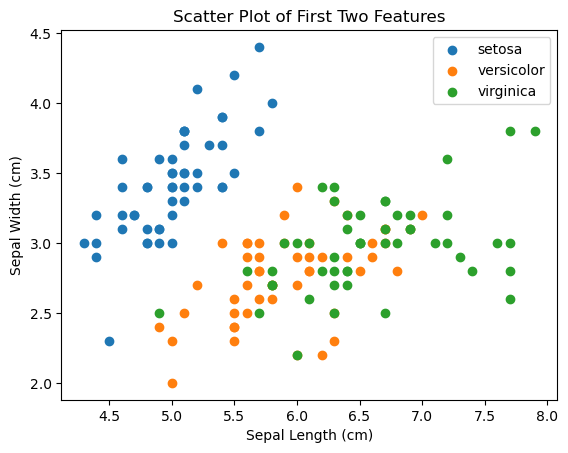

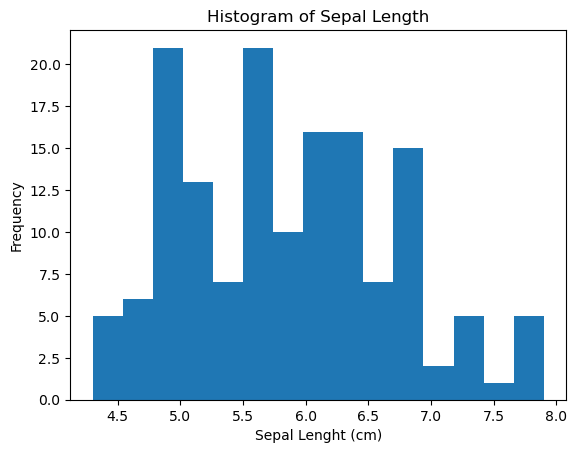

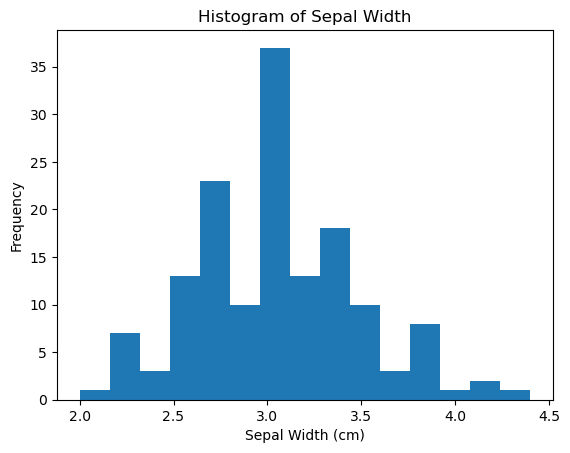

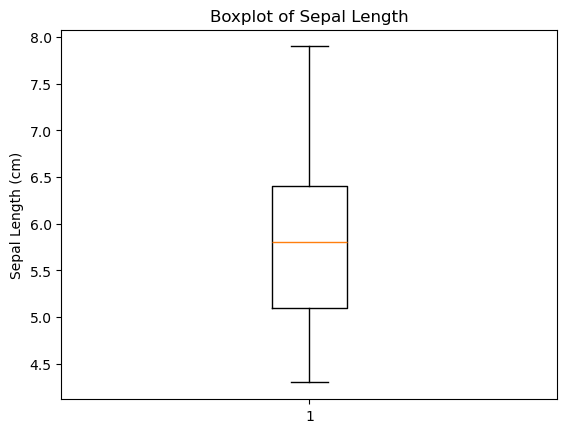

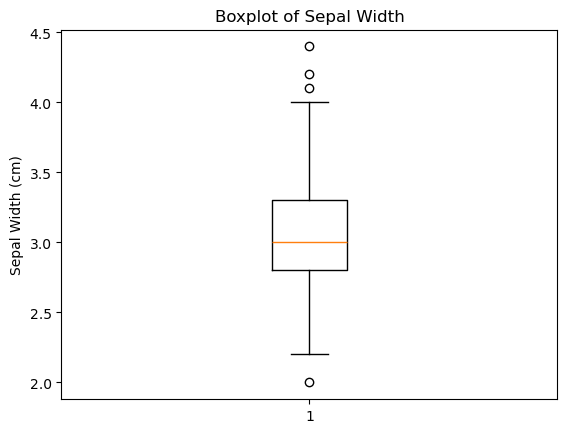

In [13]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()

# -------------------------------------------------
# 1. Explore the structure of the loaded object
# -------------------------------------------------

print("Type of iris object:")
print(type(iris), "\n")

print("Available keys in the dataset:")
print(iris.keys(), "\n")

print("Dataset description (first 500 characters):")
print(iris.DESCR[:500], "\n")


# -------------------------------------------------
# 2. Extract different parts into separate variables
# -------------------------------------------------

X_full = iris.data              # All feature values (150x4)
y = iris.target                 # Target labels (150,)
feature_names = iris.feature_names
target_names = iris.target_names

print("Shape of full feature matrix:", X_full.shape)
print("Shape of target vector:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names, "\n")


# -------------------------------------------------
# 3. Work only with the first two features
# -------------------------------------------------

X = X_full[:, :2]   # Keep only sepal length and sepal width

print("Shape of new feature matrix (first two features only):", X.shape)
print("First 5 rows of X:\n", X[:5], "\n")


# -------------------------------------------------
# 4. Convert to a DataFrame for easier exploration
# -------------------------------------------------

df = pd.DataFrame(X, columns=feature_names[:2])
df["target"] = y
df["species"] = df["target"].apply(lambda i: target_names[i])

print("First 5 rows of the DataFrame:")
print(df.head(), "\n")


# -------------------------------------------------
# 5. Basic statistical exploration
# -------------------------------------------------

print("Summary statistics:")
print(df.describe(), "\n")

print("Class distribution:")
print(df["species"].value_counts())

# -------------------------------------------------
# 6. Visualization
# -------------------------------------------------
# Scatterplot
plt.figure()
for i in range(len(target_names)):
    plt.scatter(
        X[y == i, 0], 
        X[y == i, 1], 
        label=target_names[i]
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Scatter Plot of First Two Features")
plt.legend()
plt.show()

# Histogram
plt.figure()
plt.hist(X[:,0], bins=15)
plt.xlabel("Sepal Lenght (cm)")
plt.ylabel("Frequency")
plt.title("Histogram of Sepal Length")
plt.show()

plt.figure()
plt.hist(X[:,1], bins=15)
plt.xlabel("Sepal Width (cm)")
plt.ylabel("Frequency")
plt.title("Histogram of Sepal Width")
plt.show()

# Boxplot
plt.figure()
plt.boxplot(X[:,0])
plt.ylabel("Sepal Length (cm)")
plt.title("Boxplot of Sepal Length")
plt.show()

plt.figure()
plt.boxplot(X[:, 1])
plt.ylabel("Sepal Width (cm)")
plt.title("Boxplot of Sepal Width")
plt.show()

## Inspect the feature distributions

Here we use the seaborn library, but you can also use other libraries if you want.

Label the plot (what is each boxplot, what is on the axis). You can also try other types of plots, for example violin plot.  

Hint1: https://seaborn.pydata.org/generated/seaborn.boxplot.html  
Hint2: https://seaborn.pydata.org/generated/seaborn.violinplot.html

<Axes: >

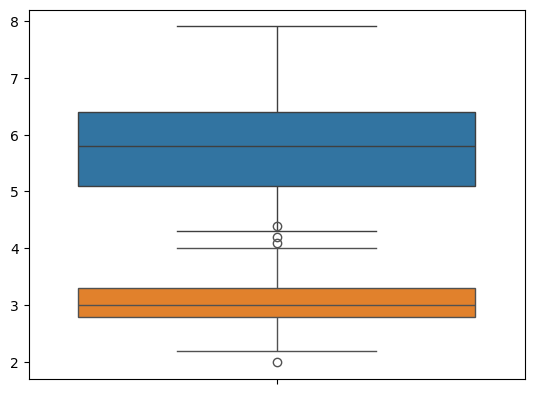

In [24]:
import seaborn as sns #For feature visualization options

# your code here
sns.boxplot(X[:,0])
sns.boxplot(X[:,1])



Let's try the violin plot as suggested 

<Axes: >

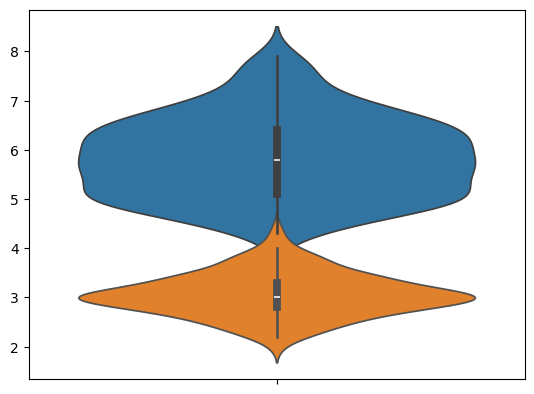

In [25]:
# your code here
sns.violinplot(X[:,0])
sns.violinplot(X[:,1])

## Feature scaling

We can see that the features are on different scales, we can transform them with the preprocessing package  

Hint: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
Hint2: Pay special attention to the `fit()` and `transform()` methods

[-1.69031455e-15 -1.84297022e-15]
[1. 1.]


C:\Users\Maribel ITU\AppData\Local\Temp\ipykernel_19708\2050508740.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(iris.feature_names[:2])


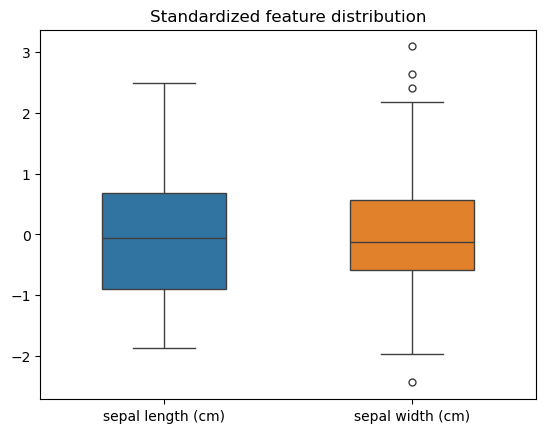

In [ ]:
from sklearn import preprocessing 

# your code here (hints below)

#Fit scaler on our data

#Apply to data itself. Later in the course, the scaler will be estimated on the training data, and then applied both to training and test data

#Verify that the features are now scaled

# Plot the feature distributions, with the scle


## Viewing features together

A different alternative is to look at features jointly with a pairplot.

Pairplot needs a DataFrame (pandas) where all the information about the data is stored together, so we need to create that first  

Hint: https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [15]:
import pandas as pd

iris_df = pd.DataFrame(features, columns=iris.feature_names[:2]) 
iris_df['label'] = [iris.target_names[label] for label in labels]

iris_df.head() #this displays the top rows in the dataframe in a nice format

,sepal length (cm),sepal width (cm),label
0,5.1,3.5,setosa
1,4.9,3.0,setosa
2,4.7,3.2,setosa
3,4.6,3.1,setosa
4,5.0,3.6,setosa


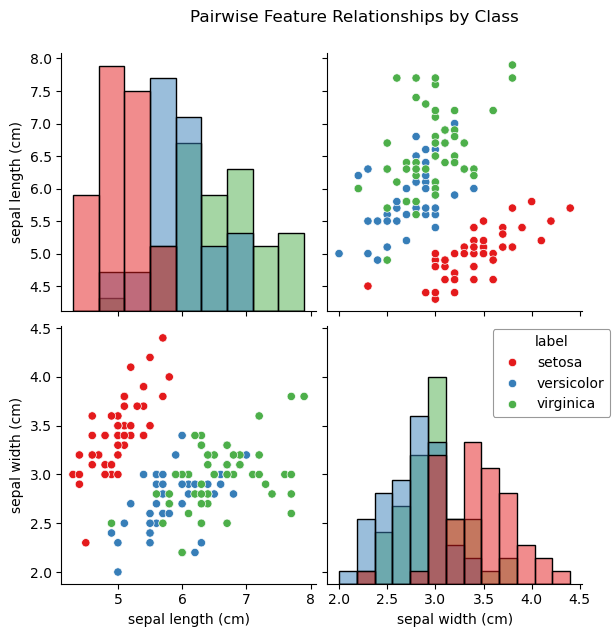

In [ ]:
# Look at pairs of features

# your code here

What interesting conclusions can you draw from this plot?

It is nice to see the separation of classes in the scatterplot, and we get an idea of the overall feature distribution in the histograms, however it'd be better to see those features distributions within each class more clearly. Plot a boxplot for each feature, discriminating by class.

Text(0.5, 1.0, 'Feature distribution by label')

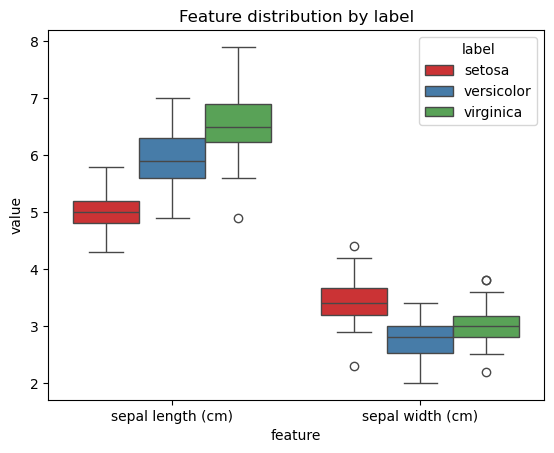

In [ ]:
# your code here